# Exploring NAT4 — the deepSTRF data paradigm in action

This notebook walks through the **NAT4** dataset (Pennington & David
2023; auto-downloaded from Zenodo) as a hands-on tour of the deepSTRF
data API. NAT4 is the dataset that exercises every subtle bit of the
[`data_paradigm.md`](../docs/_source/md/data_paradigm.md):

- **Sparse coverage** — not every cell saw every stimulus (33 of 849 A1
  cells have no validation data); missing pairs are NaN-padded sentinels.
- **Estimation / validation split** — 575 est + 18 val stims, with a
  `stim_meta['subset']` tag and a `subset='all'|'est'|'val'`
  constructor shortcut.
- **Per-cell metadata** richness — cell IDs parsed into site / animal /
  electrode / unit-in-electrode + auditory / depth tags.
- **The bidirectional rule** — selecting a stim subset auto-hides
  neurons whose only valid responses lie outside that subset.
- **`valid_mask`** — the bool grid the dataloader emits alongside
  responses, derived from NaN sentinels at collate time.

We focus on A1 here; the notebook closes with a brief PEG comparison and
a cross-area concatenation example.


## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from collections import Counter
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.NAT4_Dataset import NAT4_Dataset
from deepSTRF.utils.data import neural_collate, concat_neural_datasets


## 1. Load NAT4 A1

`NAT4_Dataset(area='A1', download=True)` fetches 3 archives from Zenodo
(~30 MB main + ~70 MB single-sites + 70 kB CSV) and unpacks them under
`~/.cache/deepSTRF/NAT4/A1/`. Subsequent loads use the cache. The
default `subset='all'` loads both estimation and validation stims; for
training-only workflows, `subset='est'` loads only the 575 estimation
stims (faster).

In [2]:
ds = NAT4_Dataset(area='A1', download=True, subset='all')
print(f"Cells:    {ds.N_neurons}")
print(f"Stimuli:  {len(ds.stims)}")
counts = Counter(m['subset'] for m in ds.stim_meta)
print(f"  est:    {counts['est']}")
print(f"  val:    {counts['val']}")
print(f"Spec shape: {tuple(ds.stims[0].shape)}  (1, F, T) at dt={ds.dt} ms")


NAT4 A1 val sites:   0%|          | 0/22 [00:00<?, ?it/s]

NAT4 A1 val sites:   5%|▍         | 1/22 [00:00<00:07,  2.84it/s]

NAT4 A1 val sites:   9%|▉         | 2/22 [00:00<00:05,  3.78it/s]

NAT4 A1 val sites:  14%|█▎        | 3/22 [00:01<00:06,  2.87it/s]

NAT4 A1 val sites:  18%|█▊        | 4/22 [00:01<00:06,  2.70it/s]

...

NAT4 A1 val sites:  91%|█████████ | 20/22 [00:08<00:01,  1.99it/s]

NAT4 A1 val sites:  95%|█████████▌| 21/22 [00:08<00:00,  1.99it/s]

NAT4 A1 val sites: 100%|██████████| 22/22 [00:08<00:00,  2.31it/s]

NAT4 A1 val sites: 100%|██████████| 22/22 [00:08<00:00,  2.50it/s]

Cells:    849
Stimuli:  593
  est:    575
  val:    18
Spec shape: (1, 18, 150)  (1, F, T) at dt=10.0 ms


## 2. Per-cell metadata

Every neuron carries a metadata dict with the cell ID parsed into its
recording site, animal (3-letter prefix), electrode, and
unit-in-electrode. NAT4 also marks the auditory-vs-non-auditory
classification used by Pennington & David (2023).

In [3]:
print("First 3 entries:")
for n in ds.neuron_metadata[:3]:
    print(f"  {n}")
print()
n_auditory = sum(1 for n in ds.neuron_metadata if n['auditory'])
print(f"auditory cells: {n_auditory} / {ds.N_neurons}")
animals = Counter(n['animal'] for n in ds.neuron_metadata)
print(f"animals:        {dict(animals)}")
sites = Counter(n['site'] for n in ds.neuron_metadata)
print(f"recording sites: {len(sites)} unique  (top 5: {sites.most_common(5)})")


First 3 entries:
  {'cell_id': 'ARM029a-04-1', 'area': 'A1', 'auditory': True, 'site': 'ARM029a', 'animal': 'ARM', 'electrode': 4, 'unit_in_electrode': 1}
  {'cell_id': 'ARM029a-07-6', 'area': 'A1', 'auditory': True, 'site': 'ARM029a', 'animal': 'ARM', 'electrode': 7, 'unit_in_electrode': 6}
  {'cell_id': 'ARM029a-07-7', 'area': 'A1', 'auditory': True, 'site': 'ARM029a', 'animal': 'ARM', 'electrode': 7, 'unit_in_electrode': 7}

auditory cells: 777 / 849
animals:        {'ARM': 165, 'CRD': 36, 'DRX': 244, 'TNC': 404}
recording sites: 22 unique  (top 5: [('DRX006b', 95), ('DRX008b', 86), ('DRX007a', 63), ('TNC018a', 60), ('TNC017a', 57)])


## 3. Coverage map — `nrn_masks`

`ds.nrn_masks` is a `(S, N)` bool tensor: `True` where neuron `n` has
recorded responses for stim `s`. NAT4 has dense est coverage but sparse
val coverage — the visualisation below shows the block structure.

valid (stim, cell) pairs: 502,863 / 503,457  (99.9%)


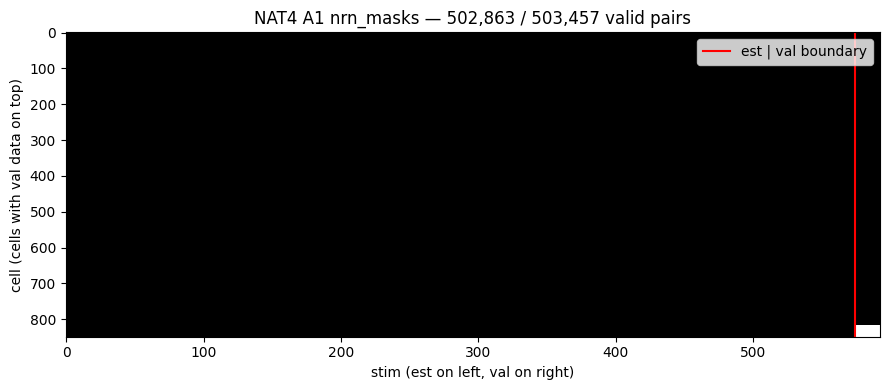

cells with ≥1 val response: 816 / 849
cells with NO val data:     33


In [4]:
masks = ds.nrn_masks                                      # (S=593, N=849)
S, N = masks.shape
total = S * N
valid = masks.sum().item()
print(f"valid (stim, cell) pairs: {valid:,} / {total:,}  ({100*valid/total:.1f}%)")

# Order stims by est/val and cells by val-data presence so the structure is visible.
stim_order = sorted(range(S), key=lambda s: ds.stim_meta[s]['subset'])
val_idx = [s for s in stim_order if ds.stim_meta[s]['subset'] == 'val']
n_val_stims = len(val_idx)

has_val = masks[val_idx].any(dim=0)                       # (N,) — True if cell has any val response
cell_order = torch.argsort(has_val.long(), descending=True)

reordered = masks[stim_order][:, cell_order]
fig, ax = plt.subplots(figsize=(9, 4))
ax.imshow(reordered.numpy().T, aspect='auto', cmap='Greys', interpolation='nearest')
ax.axvline(S - n_val_stims - 0.5, color='red', lw=1.5, label=f'est | val boundary')
ax.set_xlabel("stim (est on left, val on right)")
ax.set_ylabel("cell (cells with val data on top)")
ax.set_title(f"NAT4 A1 nrn_masks — {valid:,} / {total:,} valid pairs")
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

n_cells_with_val = has_val.sum().item()
print(f"cells with ≥1 val response: {n_cells_with_val} / {N}")
print(f"cells with NO val data:     {N - n_cells_with_val}")


## 4. Stim metadata + one example stim/response

The estimation stims and validation stims share the same
spectrogram-extraction pipeline; what differs is the trial count
(typically 1 repeat for est vs ~10-20 for val). Below: a validation
stim spectrogram and the response of one auditory cell.

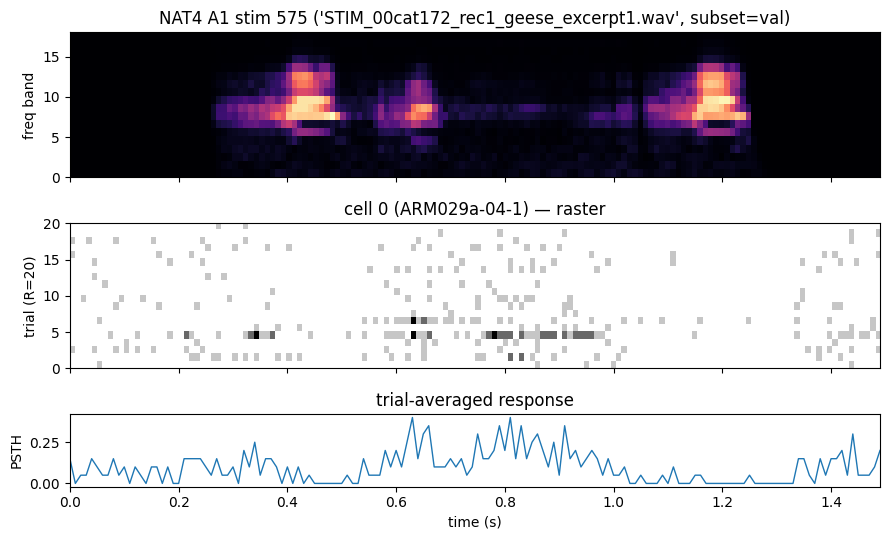

In [5]:
# Find a val stim with a high-coverage auditory cell.
val_stim_indices = [s for s, m in enumerate(ds.stim_meta) if m['subset'] == 'val']
auditory_cell_indices = [i for i, n in enumerate(ds.neuron_metadata) if n['auditory']]
for cell_idx in auditory_cell_indices:
    valid_val_stims = [s for s in val_stim_indices if not ds.responses[s][cell_idx].isnan().all()]
    if valid_val_stims:
        stim_idx = valid_val_stims[0]
        break

spec = ds.stims[stim_idx][0].numpy()                       # (F, T)
resp = ds.responses[stim_idx][cell_idx].numpy()            # (R, T)
psth = np.nanmean(resp, axis=0)
t = np.arange(spec.shape[1]) * ds.dt * 1e-3                 # seconds

fig, axs = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True,
                        gridspec_kw={"height_ratios": [2, 2, 1]})
axs[0].imshow(spec, aspect="auto", origin="lower", cmap="magma",
              extent=[t[0], t[-1], 0, spec.shape[0]])
axs[0].set_ylabel("freq band")
axs[0].set_title(f"NAT4 A1 stim {stim_idx} ('{ds.stim_meta[stim_idx]['name']}', subset={ds.stim_meta[stim_idx]['subset']})")

axs[1].imshow(resp, aspect="auto", cmap="Greys",
              extent=[t[0], t[-1], 0, resp.shape[0]])
axs[1].set_ylabel(f"trial (R={resp.shape[0]})")
axs[1].set_title(f"cell {cell_idx} ({ds.neuron_metadata[cell_idx]['cell_id']}) — raster")

axs[2].plot(t, psth, lw=1.0)
axs[2].set_ylabel("PSTH")
axs[2].set_xlabel("time (s)")
axs[2].set_title("trial-averaged response")
plt.tight_layout(); plt.show()


## 5. The bidirectional rule

`select_stims_by_attr('subset', 'val')` filters down to validation
stims. Because we now restrict the stim set, neurons whose **only**
valid responses lie outside the selection (i.e. the val-less cells
visible in §3) are auto-hidden. This is the bidirectional rule from
[`data_paradigm.md`](../docs/_source/md/data_paradigm.md) §8: a stim
selection implicitly induces a population selection.

After the selection:
- Stims drop from 593 to 18 (only validation stims remain).
- Cells drop from 849 to 816 (the 33 val-less cells are hidden).

In [6]:
ds.select_stims_by_attr('subset', 'val')

n_visible_cells = ds.nrn_masks.sum(dim=0).gt(0).sum().item() if ds.S_sel is None else len(ds._selected())
print(f"after select_stims_by_attr('subset', 'val'):")
print(f"  visible stims:  {len(ds.S_sel) if ds.S_sel is not None else len(ds.stims)}")
print(f"  visible cells:  {len(ds._selected())}")

# What __getitem__ returns now: only val-data cells, only val stims.
stim, responses_per_neuron, _, meta = ds[0]
print(f"\nfirst returned item:")
print(f"  stim shape:  {tuple(stim.shape)}")
print(f"  N returned:  {len(responses_per_neuron)}")
print(f"  meta:        {meta}")

# undo selection so subsequent cells see the full dataset
ds.reset_stim_selection()
ds.reset_pop_selection()


after select_stims_by_attr('subset', 'val'):
  visible stims:  18


  visible cells:  816



first returned item:
  stim shape:  (1, 18, 150)
  N returned:  816
  meta:        {'name': 'STIM_00cat172_rec1_geese_excerpt1.wav', 'subset': 'val'}


## 6. Population filtering — `select_pop_by_nrn_attr`

The neuron-axis filters work on any key in `neuron_metadata`. Two
common cases: keeping only auditory cells, and slicing by animal /
recording site.

In [7]:
ds.select_pop_by_nrn_attr('auditory', True)
print(f"after select_pop_by_nrn_attr('auditory', True): {len(ds._selected())} cells")
ds.reset_pop_selection()

ds.select_pop_by_nrn_attr('animal', 'ARM')
print(f"after select_pop_by_nrn_attr('animal', 'ARM'):  {len(ds._selected())} cells")
ds.reset_pop_selection()


after select_pop_by_nrn_attr('auditory', True): 777 cells
after select_pop_by_nrn_attr('animal', 'ARM'):  165 cells


## 7. The `valid_mask` from `neural_collate`

When the dataset feeds a `DataLoader` with `neural_collate`, the
collator emits a fine-grained `(B, N, R, T)` bool mask alongside the
NaN-padded responses tensor. Loss code uses this directly (see
[`metrics_paradigm.md`](../docs/_source/md/metrics_paradigm.md) §4) —
no need to re-scan for NaN positions.

In [8]:
# small batched loader (val stims, restricted to auditory cells)
ds.select_stims_by_attr('subset', 'val')
ds.select_pop_by_nrn_attr('auditory', True)
loader = DataLoader(ds, batch_size=4, shuffle=False, collate_fn=neural_collate)
stims, responses, valid_mask, stim_metas = next(iter(loader))
print(f"stims:      {tuple(stims.shape)}  (B, 1, F, T)")
print(f"responses:  {tuple(responses.shape)}  (B, N, R_max, T_max)")
print(f"valid_mask: {tuple(valid_mask.shape)}  bool")
print(f"NaN cells in responses: {responses.isnan().sum().item():,} / {responses.numel():,}")
print(f"valid_mask True count:  {valid_mask.sum().item():,}  (should equal numel - NaN count)")
ds.reset_stim_selection()
ds.reset_pop_selection()


stims:      (4, 1, 18, 150)  (B, 1, F, T)
responses:  (4, 744, 20, 150)  (B, N, R_max, T_max)
valid_mask: (4, 744, 20, 150)  bool
NaN cells in responses: 0 / 8,928,000
valid_mask True count:  8,928,000  (should equal numel - NaN count)


## 8. The PEG companion

NAT4 ships a second area, **PEG** (parabelt secondary auditory cortex).
Same protocol, different population.

In [9]:
ds_peg = NAT4_Dataset(area='PEG', download=True, subset='all')
print(f"PEG: {ds_peg.N_neurons} cells, {len(ds_peg.stims)} stims")
peg_auditory = sum(1 for n in ds_peg.neuron_metadata if n['auditory'])
print(f"  auditory: {peg_auditory} / {ds_peg.N_neurons}")
peg_total = ds_peg.nrn_masks.sum().item()
peg_grid = ds_peg.nrn_masks.numel()
print(f"  coverage: {peg_total:,} / {peg_grid:,} valid pairs ({100*peg_total/peg_grid:.1f}%)")
print(f"  animals:  {dict(Counter(n['animal'] for n in ds_peg.neuron_metadata))}")


/home/ulysse/miniconda3/envs/deepstrf_dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


download PEG_NAT4_ozgf.fs100.ch18.tgz:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

download PEG_NAT4_ozgf.fs100.ch18.tgz:   5%|▍         | 1.05M/22.4M [00:00<00:12, 1.71MB/s]

download PEG_NAT4_ozgf.fs100.ch18.tgz:   9%|▉         | 2.10M/22.4M [00:00<00:07, 2.80MB/s]

download PEG_NAT4_ozgf.fs100.ch18.tgz:  19%|█▉        | 4.19M/22.4M [00:00<00:03, 5.96MB/s]

...

NAT4 PEG val sites:  92%|█████████▏| 11/12 [00:03<00:00,  3.95it/s]

NAT4 PEG val sites: 100%|██████████| 12/12 [00:04<00:00,  3.13it/s]

NAT4 PEG val sites: 100%|██████████| 12/12 [00:04<00:00,  2.98it/s]

PEG: 398 cells, 593 stims
  auditory: 339 / 398


  coverage: 236,014 / 236,014 valid pairs (100.0%)
  animals:  {'ARM': 398}


## 9. Cross-area concatenation

`concat_neural_datasets([a1, peg])` builds a block-diagonal joint
dataset along both stim and neuron axes — A1's neurons see only A1's
stimuli (and vice versa) via NaN sentinels. A single population model
over the union jointly fits both areas. See
[`dataset_concatenation.md`](../docs/_source/md/dataset_concatenation.md).

joint dataset:
  cells:  1247
  stims:  1186


  coverage: 738,877 / 1,478,942 valid pairs (50.0%)


  cross-area sanity: 738,877 == 738,877


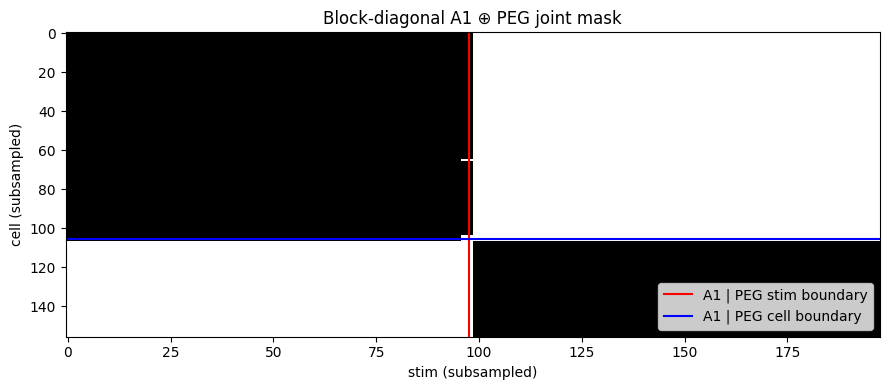

In [10]:
joint = concat_neural_datasets([ds, ds_peg])
print(f"joint dataset:")
print(f"  cells:  {joint.N_neurons}")
print(f"  stims:  {len(joint.stims)}")
joint_total = joint.nrn_masks.sum().item()
joint_grid = joint.nrn_masks.numel()
print(f"  coverage: {joint_total:,} / {joint_grid:,} valid pairs ({100*joint_total/joint_grid:.1f}%)")
print(f"  cross-area sanity: {ds.nrn_masks.sum().item() + ds_peg.nrn_masks.sum().item():,} == {joint_total:,}")

# verify the block-diagonal structure visually for a small subsample
fig, ax = plt.subplots(figsize=(9, 4))
sub = joint.nrn_masks[::6, ::8]    # every 6th stim, every 8th cell
ax.imshow(sub.numpy().T, aspect='auto', cmap='Greys', interpolation='nearest')
ax.axvline(len(ds.stims) // 6 - 0.5, color='red', lw=1.5, label='A1 | PEG stim boundary')
ax.axhline(ds.N_neurons // 8 - 0.5, color='blue', lw=1.5, label='A1 | PEG cell boundary')
ax.set_xlabel("stim (subsampled)")
ax.set_ylabel("cell (subsampled)")
ax.set_title("Block-diagonal A1 ⊕ PEG joint mask")
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


## What's next

- **End-to-end fit on NAT4** — the same `Fitter`/metrics stack from
  [`fit_ns1_statenet.ipynb`](fit_ns1_statenet.ipynb) ports to NAT4
  unchanged. The non-trivial bit is the est/val split: NAT4 already
  ships it, so use `subset='est'` for the train/val loaders and
  `subset='val'` for held-out evaluation.
- **Cross-species pooling** — replace the A1+PEG concat above with
  e.g. NS1+NAT4_A1 to fit ferret + ferret jointly, or with CRCNS_AA1
  for cross-species.
- **Stim selection tricks** — the bidirectional rule (§5) makes
  per-stim-class evaluation a one-liner. Useful when reporting cc_norm
  on a particular stimulus class.
